# Context Window Ablation: Untrained STATE vs RP (PBMC 46k)

Compare untrained STATE embeddings and random projections at two context windows (512 vs 2048 genes).
STATE's `pad_length` controls how many top-expressed genes per cell enter the transformer.
RP uses the N genes with highest mean expression across test cells.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.expanduser(
    "~/noise_scaling/modeling/Scaling-up-measurement-noise-scaling-laws/scaling_laws/src"
))

from pathlib import Path
from datetime import datetime
import random
import subprocess, textwrap, tempfile
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import torch, yaml
from sklearn.random_projection import GaussianRandomProjection
import scipy.sparse as sp

from scaling_laws.algo import State

DATA_DIR = Path(os.path.expanduser("~/noise_scaling/data"))
DATASET = "PBMC"
SIZE = 46_415
QUALITY = 1.0
DEVICE = random.randint(0, torch.cuda.device_count() - 1)
SEED = 42
RUN_DATE = datetime.now().strftime("%Y-%m-%d")

base_dir = DATA_DIR / DATASET / str(SIZE) / str(QUALITY)
results_root = base_dir / "results"

# Load test data (shared across RP sections)
test_h5ad = DATA_DIR / DATASET / "test" / str(QUALITY) / "preprocessed" / "preprocessed.h5ad"
test_adata = ad.read_h5ad(test_h5ad)
X_test = test_adata.X
if sp.issparse(X_test):
    mean_expr = np.asarray(X_test.mean(axis=0)).ravel()
else:
    mean_expr = X_test.mean(axis=0)
print(f"Test data: {test_adata.shape}")
print(f"Results root: {results_root}")
print(f"GPU device: {DEVICE}")
print(f"Run date: {RUN_DATE}")

/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Test data: (27503, 20729)
Results root: /home/igor/noise_scaling/data/PBMC/46415/1.0/results
GPU device: 2
Run date: 2026-04-14


## 1. State untrained (512 genes)

In [2]:
pad_length = 512
result_dir = results_root / f"{RUN_DATE}_State_untrained_512" / "model"
result_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = result_dir / "untrained.ckpt"

# Create untrained checkpoint in the STATE conda env
script = textwrap.dedent(f"""\
    import torch
    from torch import nn
    from omegaconf import OmegaConf
    from state.emb.nn.model import StateEmbeddingModel
    from state.emb.utils import get_embedding_cfg
    from state.emb.train.trainer import get_embeddings

    cfg = OmegaConf.load("{base_dir / 'preprocessed' / 'state_data' / 'state_config.yaml'}")
    profile_name = "scaling_{DATASET}_{SIZE}_{str(QUALITY).replace('.', '_')}"

    cfg.embeddings.current = profile_name
    cfg.dataset.current = profile_name
    cfg.dataset.pad_length = {pad_length}
    cfg.model.batch_size = 128
    cfg.model.emsize = 256
    cfg.model.d_hid = 512
    cfg.model.nhead = 4
    cfg.model.nlayers = 3
    cfg.model.output_dim = 256
    cfg.model.dataset_correction = False
    cfg.model.dropout = 0.1

    emb_cfg = get_embedding_cfg(cfg)
    print(f"Token dim: {{emb_cfg.size}}, pad_length: {{cfg.dataset.pad_length}}")

    model = StateEmbeddingModel(
        token_dim=emb_cfg.size, d_model=cfg.model.emsize,
        nhead=cfg.model.nhead, d_hid=cfg.model.d_hid,
        nlayers=cfg.model.nlayers, output_dim=cfg.model.output_dim,
        dropout=0.0, warmup_steps=0, compiled=False,
        max_lr=5e-4, emb_size=emb_cfg.size, cfg=cfg,
    )

    all_pe = get_embeddings(cfg)
    all_pe.requires_grad = False
    model.pe_embedding = nn.Embedding.from_pretrained(all_pe)
    model = model.cuda()

    import lightning as L
    trainer = L.Trainer(accelerator='cuda', devices=1, logger=False,
                        enable_checkpointing=False)
    trainer.strategy.connect(model)
    trainer.save_checkpoint("{ckpt_path}")
    print(f"Saved untrained checkpoint to {ckpt_path}")
""")

with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
    f.write(script)
    script_path = f.name

env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = str(DEVICE)
result = subprocess.run(
    ["/home/igor/miniconda3/envs/state/bin/python", script_path],
    cwd="/home/igor/noise_scaling/modeling/STATE/state",
    env=env, capture_output=True, text=True,
)
os.unlink(script_path)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

# Embed
m = State(base_dir=str(base_dir), device=DEVICE, max_epochs=0,
          dataset_name=DATASET, seed=SEED)
m.save_folder_path = results_root / f"{RUN_DATE}_State_untrained_512"
m.model_name = "model"
m.embeddings_path = result_dir / "embeddings.csv"
m.checkpoint_dir = result_dir

emb = m.embed()
pd.DataFrame(emb).to_csv(m.embeddings_path, index=False)
print(f"Embeddings: {emb.shape}")

# LMI
m.signal_columns = ["protein_counts"]
for sig, mi in m.mutual_information(max_epochs=300).items():
    print(f"LMI {sig}: {mi:.5f}")

Token dim: 2560, pad_length: 512
Saved untrained checkpoint to /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_512/model/untrained.ckpt



Using GPU 2 (visible as cuda:0)
  Using checkpoint: /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_512/model/untrained.ckpt
  Running: /home/igor/miniconda3/envs/state/bin/python -m state emb transform --checkpoint /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_512/model/untrained.ckpt --input /home/igor/noise_scaling/data/PBMC/test/1.0/preprocessed/preprocessed.h5ad --output /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_512/model/embeddings.npy


INFO:state._cli._emb._transform:Using model checkpoint: /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_512/model/untrained.ckpt
INFO:state._cli._emb._transform:Creating inference object
INFO:state._cli._emb._transform:Loading model from checkpoint: /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_512/model/untrained.ckpt


INFO:state._cli._emb._transform:Created output directory: /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_512/model
INFO:state._cli._emb._transform:Computing embeddings for /home/igor/noise_scaling/data/PBMC/test/1.0/preprocessed/preprocessed.h5ad
INFO:state._cli._emb._transform:Output will be saved to /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_512/model/embeddings.npy as a NumPy array of embeddings only (no embedded .h5ad will be written)


INFO:state.emb.inference:Auto-detected gene column: var.index (overlap: 14899/42940 protein embeddings, 71.9% of genes)
INFO:/home/igor/noise_scaling/modeling/STATE/state/src/state/emb/data/loader.py:14899 genes mapped to embedding file (out of 20729)


...


epoch 49 (of max 300) 🌻


epoch 50 (of max 300) 🌻 🎉🎉


success! training stopped at epoch 50
final validation loss: 2.442303839851828


State MI for Y_protein_counts_1.0 at PBMC quality 1.0 size 46415: 1.2921907026348067
Saving results to /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_512/model/MI/42/Y_protein_counts_1.0


LMI Y_celltype.l3_1.0.csv: 1.69693
LMI Y_protein_counts_1.0.csv: 1.29219


## 2. State untrained (2048 genes)

In [3]:
pad_length = 2048
result_dir = results_root / f"{RUN_DATE}_State_untrained_2048" / "model"
result_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = result_dir / "untrained.ckpt"

# Create untrained checkpoint in the STATE conda env
script = textwrap.dedent(f"""\
    import torch
    from torch import nn
    from omegaconf import OmegaConf
    from state.emb.nn.model import StateEmbeddingModel
    from state.emb.utils import get_embedding_cfg
    from state.emb.train.trainer import get_embeddings

    cfg = OmegaConf.load("{base_dir / 'preprocessed' / 'state_data' / 'state_config.yaml'}")
    profile_name = "scaling_{DATASET}_{SIZE}_{str(QUALITY).replace('.', '_')}"

    cfg.embeddings.current = profile_name
    cfg.dataset.current = profile_name
    cfg.dataset.pad_length = {pad_length}
    cfg.model.batch_size = 128
    cfg.model.emsize = 256
    cfg.model.d_hid = 512
    cfg.model.nhead = 4
    cfg.model.nlayers = 3
    cfg.model.output_dim = 256
    cfg.model.dataset_correction = False
    cfg.model.dropout = 0.1

    emb_cfg = get_embedding_cfg(cfg)
    print(f"Token dim: {{emb_cfg.size}}, pad_length: {{cfg.dataset.pad_length}}")

    model = StateEmbeddingModel(
        token_dim=emb_cfg.size, d_model=cfg.model.emsize,
        nhead=cfg.model.nhead, d_hid=cfg.model.d_hid,
        nlayers=cfg.model.nlayers, output_dim=cfg.model.output_dim,
        dropout=0.0, warmup_steps=0, compiled=False,
        max_lr=5e-4, emb_size=emb_cfg.size, cfg=cfg,
    )

    all_pe = get_embeddings(cfg)
    all_pe.requires_grad = False
    model.pe_embedding = nn.Embedding.from_pretrained(all_pe)
    model = model.cuda()

    import lightning as L
    trainer = L.Trainer(accelerator='cuda', devices=1, logger=False,
                        enable_checkpointing=False)
    trainer.strategy.connect(model)
    trainer.save_checkpoint("{ckpt_path}")
    print(f"Saved untrained checkpoint to {ckpt_path}")
""")

with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
    f.write(script)
    script_path = f.name

env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = str(DEVICE)
result = subprocess.run(
    ["/home/igor/miniconda3/envs/state/bin/python", script_path],
    cwd="/home/igor/noise_scaling/modeling/STATE/state",
    env=env, capture_output=True, text=True,
)
os.unlink(script_path)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

# Embed
m = State(base_dir=str(base_dir), device=DEVICE, max_epochs=0,
          dataset_name=DATASET, seed=SEED)
m.save_folder_path = results_root / f"{RUN_DATE}_State_untrained_2048"
m.model_name = "model"
m.embeddings_path = result_dir / "embeddings.csv"
m.checkpoint_dir = result_dir

emb = m.embed()
pd.DataFrame(emb).to_csv(m.embeddings_path, index=False)
print(f"Embeddings: {emb.shape}")

# LMI
m.signal_columns = ["protein_counts"]
for sig, mi in m.mutual_information(max_epochs=300).items():
    print(f"LMI {sig}: {mi:.5f}")

Token dim: 2560, pad_length: 2048
Saved untrained checkpoint to /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_2048/model/untrained.ckpt

Using GPU 2 (visible as cuda:0)
  Using checkpoint: /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_2048/model/untrained.ckpt
  Running: /home/igor/miniconda3/envs/state/bin/python -m state emb transform --checkpoint /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_2048/model/untrained.ckpt --input /home/igor/noise_scaling/data/PBMC/test/1.0/preprocessed/preprocessed.h5ad --output /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_2048/model/embeddings.npy


INFO:state._cli._emb._transform:Using model checkpoint: /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_2048/model/untrained.ckpt
INFO:state._cli._emb._transform:Creating inference object
INFO:state._cli._emb._transform:Loading model from checkpoint: /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_2048/model/untrained.ckpt


INFO:state._cli._emb._transform:Created output directory: /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_2048/model
INFO:state._cli._emb._transform:Computing embeddings for /home/igor/noise_scaling/data/PBMC/test/1.0/preprocessed/preprocessed.h5ad
INFO:state._cli._emb._transform:Output will be saved to /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_2048/model/embeddings.npy as a NumPy array of embeddings only (no embedded .h5ad will be written)


INFO:state.emb.inference:Auto-detected gene column: var.index (overlap: 14899/42940 protein embeddings, 71.9% of genes)
INFO:/home/igor/noise_scaling/modeling/STATE/state/src/state/emb/data/loader.py:14899 genes mapped to embedding file (out of 20729)


!!! 14899 genes mapped to embedding file (out of 20729)


...


epoch 72 (of max 300) 🌻🌻


epoch 73 (of max 300) 🌻🌻 🎉🎉


success! training stopped at epoch 73
final validation loss: 2.189765916151159


State MI for Y_protein_counts_1.0 at PBMC quality 1.0 size 46415: 1.191291112076498
Saving results to /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_State_untrained_2048/model/MI/42/Y_protein_counts_1.0


LMI Y_celltype.l3_1.0.csv: 1.12400
LMI Y_protein_counts_1.0.csv: 1.19129


## 3. RP (top-512 genes)

In [4]:
n_top = 512
top_idx = np.sort(np.argsort(mean_expr)[::-1][:n_top])
X_sub = X_test[:, top_idx].toarray() if sp.issparse(X_test) else X_test[:, top_idx]

rp = GaussianRandomProjection(n_components=16, random_state=42)
X_rp = rp.fit_transform(X_sub)
print(f"RP embeddings: {X_rp.shape}")

out_dir = results_root / f"{RUN_DATE}_RP_top512_genes" / "model"
out_dir.mkdir(parents=True, exist_ok=True)
emb_path = out_dir / "embeddings.csv"
pd.DataFrame(X_rp).to_csv(emb_path, index=False)

# LMI
m = State(base_dir=str(base_dir), device=DEVICE, max_epochs=0,
          dataset_name=DATASET, seed=SEED)
m.save_folder_path = results_root / f"{RUN_DATE}_RP_top512_genes"
m.model_name = "model"
m.embeddings_path = emb_path
m.signal_columns = ["protein_counts"]
for sig, mi in m.mutual_information(max_epochs=300).items():
    print(f"LMI {sig}: {mi:.5f}")

RP embeddings: (27503, 16)


Using GPU 2 (visible as cuda:0)
Using GPU for LMI computation (device 2 visible as cuda:0)
Found 4 quality-specific signal files: ['Y_celltype.l3_1.0.csv', 'Y_celltype.l3_1.0_geneformer.csv', 'Y_protein_counts_1.0.csv', 'Y_protein_counts_1.0_geneformer.csv']
using signal file /home/igor/noise_scaling/data/PBMC/test/1.0/signals/Y_celltype.l3_1.0.csv



epoch 0 (of max 300) 


epoch 1 (of max 300) 


epoch 2 (of max 300) 

...


epoch 192 (of max 300) 🌻🌻🌻🌻🌻🌻


epoch 193 (of max 300) 🌻🌻🌻🌻🌻🌻


epoch 194 (of max 300) 🌻🌻🌻🌻🌻🌻 🎉🎉


success! training stopped at epoch 194
final validation loss: 1.2730313259012558


State MI for Y_protein_counts_1.0 at PBMC quality 1.0 size 46415: 2.6940973131103596
Saving results to /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_RP_top512_genes/model/MI/42/Y_protein_counts_1.0
LMI Y_celltype.l3_1.0.csv: 2.58752
LMI Y_protein_counts_1.0.csv: 2.69410


## 4. RP (top-2048 genes)

In [5]:
n_top = 2048
top_idx = np.sort(np.argsort(mean_expr)[::-1][:n_top])
X_sub = X_test[:, top_idx].toarray() if sp.issparse(X_test) else X_test[:, top_idx]

rp = GaussianRandomProjection(n_components=16, random_state=42)
X_rp = rp.fit_transform(X_sub)
print(f"RP embeddings: {X_rp.shape}")

out_dir = results_root / f"{RUN_DATE}_RP_top2048_genes" / "model"
out_dir.mkdir(parents=True, exist_ok=True)
emb_path = out_dir / "embeddings.csv"
pd.DataFrame(X_rp).to_csv(emb_path, index=False)

# LMI
m = State(base_dir=str(base_dir), device=DEVICE, max_epochs=0,
          dataset_name=DATASET, seed=SEED)
m.save_folder_path = results_root / f"{RUN_DATE}_RP_top2048_genes"
m.model_name = "model"
m.embeddings_path = emb_path
m.signal_columns = ["protein_counts"]
for sig, mi in m.mutual_information(max_epochs=300).items():
    print(f"LMI {sig}: {mi:.5f}")

RP embeddings: (27503, 16)


Using GPU 2 (visible as cuda:0)
Using GPU for LMI computation (device 2 visible as cuda:0)
Found 4 quality-specific signal files: ['Y_celltype.l3_1.0.csv', 'Y_celltype.l3_1.0_geneformer.csv', 'Y_protein_counts_1.0.csv', 'Y_protein_counts_1.0_geneformer.csv']
using signal file /home/igor/noise_scaling/data/PBMC/test/1.0/signals/Y_celltype.l3_1.0.csv



epoch 0 (of max 300) 


epoch 1 (of max 300) 


epoch 2 (of max 300) 

...


epoch 161 (of max 300) 🌻🌻🌻🌻🌻


epoch 162 (of max 300) 🌻🌻🌻🌻🌻


epoch 163 (of max 300) 🌻🌻🌻🌻🌻 🎉🎉


success! training stopped at epoch 163
final validation loss: 1.442981250145856


State MI for Y_protein_counts_1.0 at PBMC quality 1.0 size 46415: 2.9081100942445826
Saving results to /home/igor/noise_scaling/data/PBMC/46415/1.0/results/2026-04-14_RP_top2048_genes/model/MI/42/Y_protein_counts_1.0
LMI Y_celltype.l3_1.0.csv: 2.50383
LMI Y_protein_counts_1.0.csv: 2.90811


## 5. RP (all 20,729 genes)

In [6]:
# RP on all genes — already computed by the main pipeline as "RandomProjection".
# Re-compute here if MI is missing.
rp_all_dir = results_root / "RandomProjection" / "model"
mi_file = rp_all_dir / "MI" / "42" / "Y_protein_counts_1.0" / "lmi_mutual_information.txt"

if mi_file.exists():
    print(f"RP (all genes) LMI (cached): {float(mi_file.read_text().strip()):.5f}")
    print(f"  n_genes = {test_adata.shape[1]}")
else:
    X_all = X_test.toarray() if sp.issparse(X_test) else X_test
    rp = GaussianRandomProjection(n_components=16, random_state=42)
    X_rp = rp.fit_transform(X_all)
    print(f"RP embeddings: {X_rp.shape}")

    rp_all_dir.mkdir(parents=True, exist_ok=True)
    emb_path = rp_all_dir / "embeddings.csv"
    pd.DataFrame(X_rp).to_csv(emb_path, index=False)

    m = State(base_dir=str(base_dir), device=DEVICE, max_epochs=0,
              dataset_name=DATASET, seed=SEED)
    m.save_folder_path = results_root / "RandomProjection"
    m.model_name = "model"
    m.embeddings_path = emb_path
    m.signal_columns = ["protein_counts"]
    for sig, mi in m.mutual_information(max_epochs=300).items():
        print(f"LMI {sig}: {mi:.5f}")

RP (all genes) LMI (cached): 2.87480
  n_genes = 20729


## 6. RP (ESM-overlap genes)

In [7]:
# RP on genes that overlap between PBMC and ESM-2 embeddings (~14,899 genes).
# This is the gene set STATE actually sees.
# Already computed as "RP_state_genes"; re-compute if missing.
rp_esm_dir = results_root / "RP_state_genes" / "model"
mi_file = rp_esm_dir / "MI" / "42" / "Y_protein_counts_1.0" / "lmi_mutual_information.txt"

if mi_file.exists():
    print(f"RP (ESM-overlap genes) LMI (cached): {float(mi_file.read_text().strip()):.5f}")
    # Show gene count
    profile_name = f"scaling_{DATASET}_{SIZE}_{str(QUALITY).replace('.', '_')}"
    state_data_dir = base_dir / "preprocessed" / "state_data"
    mask_file = state_data_dir / f"valid_genes_masks_{profile_name}.torch"
    if mask_file.exists():
        masks = torch.load(mask_file, map_location="cpu", weights_only=False)
        test_key = [k for k in masks if "test" in k][0]
        print(f"  n_genes = {masks[test_key].sum().item()} (of {len(masks[test_key])})")
else:
    profile_name = f"scaling_{DATASET}_{SIZE}_{str(QUALITY).replace('.', '_')}"
    state_data_dir = base_dir / "preprocessed" / "state_data"
    masks = torch.load(
        state_data_dir / f"valid_genes_masks_{profile_name}.torch",
        map_location="cpu", weights_only=False,
    )
    test_key = [k for k in masks if "test" in k][0]
    gene_mask = masks[test_key].numpy()
    print(f"ESM-overlap genes: {gene_mask.sum()} of {len(gene_mask)}")

    X_esm = X_test[:, gene_mask].toarray() if sp.issparse(X_test) else X_test[:, gene_mask]
    rp = GaussianRandomProjection(n_components=16, random_state=42)
    X_rp = rp.fit_transform(X_esm)
    print(f"RP embeddings: {X_rp.shape}")

    rp_esm_dir.mkdir(parents=True, exist_ok=True)
    emb_path = rp_esm_dir / "embeddings.csv"
    pd.DataFrame(X_rp).to_csv(emb_path, index=False)

    m = State(base_dir=str(base_dir), device=DEVICE, max_epochs=0,
              dataset_name=DATASET, seed=SEED)
    m.save_folder_path = results_root / "RP_state_genes"
    m.model_name = "model"
    m.embeddings_path = emb_path
    m.signal_columns = ["protein_counts"]
    for sig, mi in m.mutual_information(max_epochs=300).items():
        print(f"LMI {sig}: {mi:.5f}")

RP (ESM-overlap genes) LMI (cached): 2.68605
  n_genes = 14899 (of 20729)


## 7. Comparison

RP (top-512 genes)              seed=42  LMI=2.69410
State untrained (512)           seed=42  LMI=1.29219
RP (top-2048 genes)             seed=42  LMI=2.90811
State untrained (2048)          seed=42  LMI=1.19129
RP (ESM-overlap, ~14.9k)        seed=42  LMI=2.68605
RP (all 20,729 genes)           seed=1404  LMI=2.87480
RP (all 20,729 genes)           seed=2303  LMI=2.86534
RP (all 20,729 genes)           seed=2701  LMI=2.87480
RP (all 20,729 genes)           seed=42  LMI=2.87480


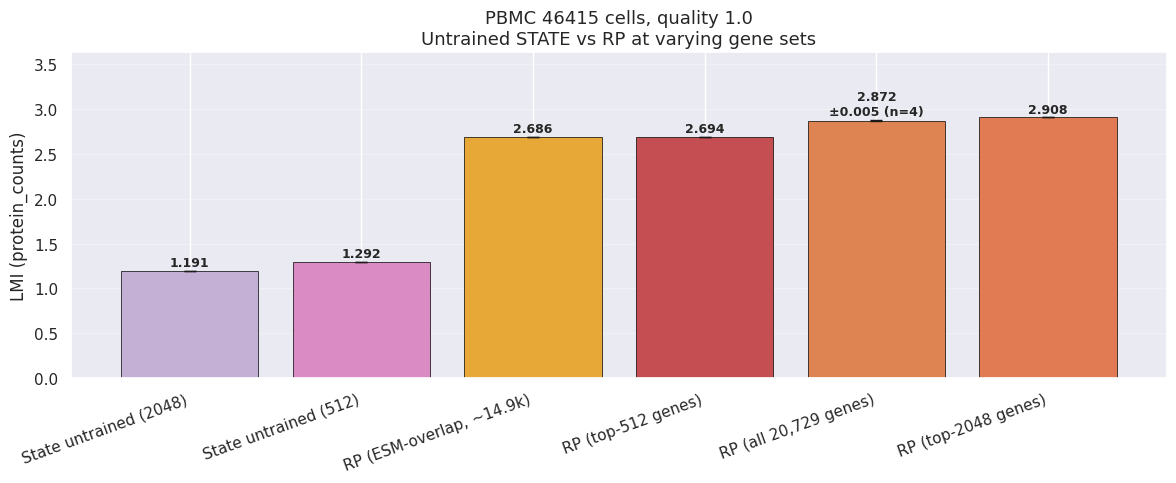


Pairwise differences:
  Context: 2048 vs 512 (RP)                      +0.2140
  Genes: 14.9k vs 2048 (RP)                      -0.2221
  Genes: all vs ESM-overlap (RP)                 +0.1864
  Context: 2048 vs 512 (STATE)                   -0.1009
  Arch: RP vs STATE (512)                        +1.4019
  Arch: RP vs STATE (2048)                       +1.7168


In [42]:
# Arrange the bars in ascending order of mean_lmi (LMI)

try:
    RUN_DATE
except NameError:
    RUN_DATE = "2026-04-14"

algos = [
    (f"{RUN_DATE}_RP_top512_genes",      "RP (top-512 genes)", 512),
    (f"{RUN_DATE}_State_untrained_512",  "State untrained (512)", 512),
    (f"{RUN_DATE}_RP_top2048_genes",     "RP (top-2048 genes)", 2048),
    (f"{RUN_DATE}_State_untrained_2048", "State untrained (2048)", 2048),
    ("RP_state_genes",                   "RP (ESM-overlap, ~14.9k)", 14901),  # approx
    ("RandomProjection",                 "RP (all 20,729 genes)", 20729),
]

# Sort by gene set size (third column)
algos = sorted(algos, key=lambda x: x[2])

rows = []
for algo_dir, algo_label, _ in algos:
    mi_base = results_root / algo_dir / "model" / "MI"
    if not mi_base.exists():
        print(f"{algo_label:30s}  NOT FOUND")
        continue
    for seed_dir in sorted(mi_base.iterdir()):
        mi_file = seed_dir / "Y_protein_counts_1.0" / "lmi_mutual_information.txt"
        if mi_file.exists():
            mi = float(mi_file.read_text().strip())
            rows.append({"Algorithm": algo_label, "seed": int(seed_dir.name), "LMI": mi})
            print(f"{algo_label:30s}  seed={seed_dir.name}  LMI={mi:.5f}")

scores = pd.DataFrame(rows)
scores_agg = (
    scores.groupby("Algorithm")["LMI"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "mean_lmi", "std": "std_lmi", "count": "n_seeds"})
    .reset_index()
)
scores_agg["std_lmi"] = scores_agg["std_lmi"].fillna(0)

colors = {
    "State untrained (512)":     "#DA8BC3",
    "State untrained (2048)":    "#C5B0D5",
    "RP (top-512 genes)":        "#C44E52",
    "RP (top-2048 genes)":       "#E07B54",
    "RP (ESM-overlap, ~14.9k)":  "#E8A838",
    "RP (all 20,729 genes)":     "#DD8452",
}

# Sort plot order by increasing mean_lmi (ascending), i.e., lowest to highest
scores_plot = scores_agg.sort_values("mean_lmi", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    scores_plot["Algorithm"], scores_plot["mean_lmi"],
    yerr=scores_plot["std_lmi"], capsize=4,
    color=[colors.get(a, "#999") for a in scores_plot["Algorithm"]],
    edgecolor="black", linewidth=0.5,
)
for bar, mean, std, n in zip(
    bars, scores_plot["mean_lmi"], scores_plot["std_lmi"], scores_plot["n_seeds"]
):
    label = f"{mean:.3f}"
    if n > 1:
        label += f"\n\u00b1{std:.3f} (n={n})"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.02,
            label, ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("LMI (protein_counts)", fontsize=12)
ax.set_title(f"PBMC {SIZE} cells, quality {QUALITY}\n"
             "Untrained STATE vs RP at varying gene sets", fontsize=13)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, (scores_plot["mean_lmi"] + scores_plot["std_lmi"]).max() * 1.25)
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
plt.show()

vals = {r["Algorithm"]: r["mean_lmi"] for _, r in scores_plot.iterrows()}
print("\nPairwise differences:")
for a, b, desc in [
    ("RP (top-2048 genes)", "RP (top-512 genes)", "Context: 2048 vs 512 (RP)"),
    ("RP (ESM-overlap, ~14.9k)", "RP (top-2048 genes)", "Genes: 14.9k vs 2048 (RP)"),
    ("RP (all 20,729 genes)", "RP (ESM-overlap, ~14.9k)", "Genes: all vs ESM-overlap (RP)"),
    ("State untrained (2048)", "State untrained (512)", "Context: 2048 vs 512 (STATE)"),
    ("RP (top-512 genes)", "State untrained (512)", "Arch: RP vs STATE (512)"),
    ("RP (top-2048 genes)", "State untrained (2048)", "Arch: RP vs STATE (2048)"),
]:
    if a in vals and b in vals:
        print(f"  {desc:45s}  {vals[a] - vals[b]:+.4f}")

   
   